# Deep LDA Results

Compare DNLLLoss vs LogisticLoss on CIFAR-10, CIFAR-100, and Fashion-MNIST across 5 runs.


In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
})


In [2]:
results_paths = {
    'Fashion-MNIST': Path('fashionmnist_lda_runs.json'),
    'CIFAR-10': Path('cifar10_lda_runs.json'),
    'CIFAR-100': Path('cifar100_lda_runs.json'),
}
results_by_dataset = {}
for dataset_name, results_path in results_paths.items():
    with results_path.open() as f:
        results_by_dataset[dataset_name] = json.load(f)

ylims = {
    'Fashion-MNIST': (92, 95),
    'CIFAR-10': (80, 95),
    'CIFAR-100': (55, 70),
}


train_ylims = {
    'Fashion-MNIST': (90, 100),
    'CIFAR-10': (90, 100),
    'CIFAR-100': (50, 100),
}
{name: results['config'] for name, results in results_by_dataset.items()}


{'Fashion-MNIST': {'dataset': 'Fashion-MNIST',
  'epochs': 100,
  'runs': 5,
  'batch_size': 256,
  'test_batch_size': 1024,
  'num_classes': 10,
  'embedding_dim': 9,
  'covariance_type': 'spherical',
  'optimizer': 'Adam',
  'lr': 0.001,
  'lambda_reg': 1.0,
  'seed_base': 1234,
  'deterministic': False,
  'device': 'cuda',
  'timestamp': '2026-05-05T01:45:45'},
 'CIFAR-10': {'dataset': 'CIFAR-10',
  'epochs': 100,
  'runs': 5,
  'batch_size': 256,
  'test_batch_size': 1024,
  'num_classes': 10,
  'embedding_dim': 9,
  'covariance_type': 'spherical',
  'optimizer': 'Adam',
  'lr': 0.001,
  'lambda_reg': 1.0,
  'seed_base': 1234,
  'deterministic': False,
  'device': 'cuda',
  'timestamp': '2026-01-08T16:53:35'},
 'CIFAR-100': {'dataset': 'CIFAR-100',
  'epochs': 100,
  'runs': 5,
  'batch_size': 256,
  'test_batch_size': 1024,
  'num_classes': 100,
  'embedding_dim': 99,
  'optimizer': 'Adam',
  'lr': 0.001,
  'lambda_reg': 1.0,
  'seed_base': 1234,
  'deterministic': False,
  'devic

In [3]:
def stack_metric(loss_runs, key):
    return np.array([run[key] for run in loss_runs], dtype=np.float32)

def summarize_metric(loss_runs, key):
    values = stack_metric(loss_runs, key)
    mean = values.mean(axis=0)
    std = values.std(axis=0)
    return mean, std

def plot_metric(ax, loss_runs, key, label, color):
    mean, std = summarize_metric(loss_runs, key)
    epochs = np.arange(1, len(mean) + 1)
    scale = 100 if key.endswith('acc') else 1
    ax.plot(epochs, mean * scale, label=label, color=color, linewidth=2)
    ax.fill_between(epochs, (mean - std) * scale, (mean + std) * scale, color=color, alpha=0.2)
    return mean, std


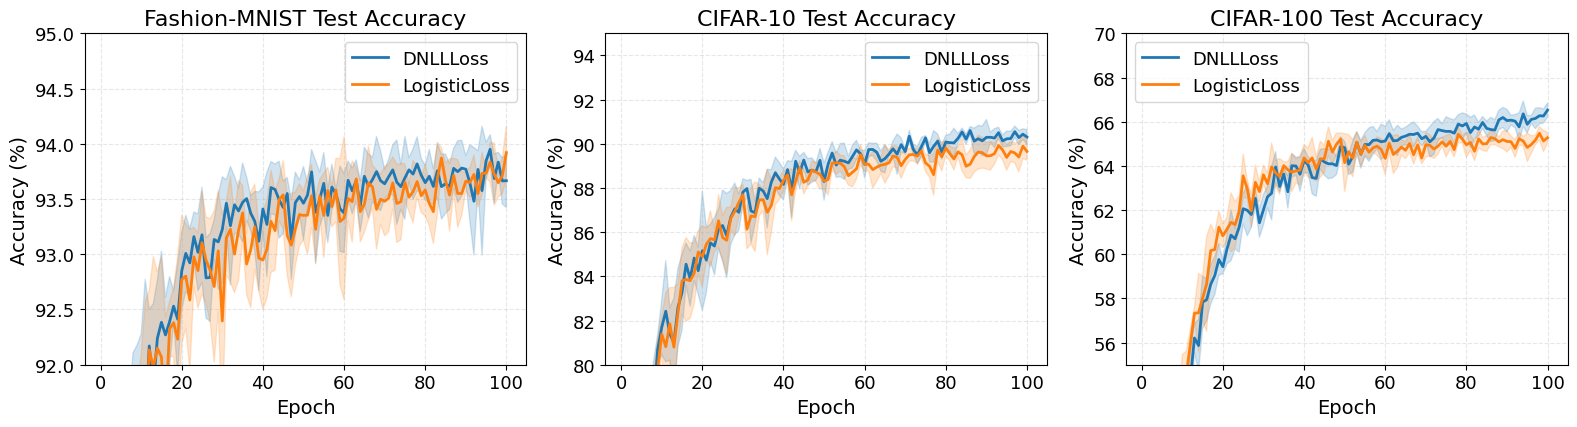

In [4]:
colors = {
    'DNLLLoss': '#1f77b4',
    'LogisticLoss': '#ff7f0e',
}

fig, axes = plt.subplots(1, len(results_by_dataset), figsize=(16, 4.5), sharey=False)

for ax, (dataset_name, results) in zip(axes, results_by_dataset.items()):
    losses = results['losses']
    for loss_name, loss_runs in losses.items():
        plot_metric(ax, loss_runs, 'test_acc', loss_name, colors[loss_name])
    ax.set_title(f'{dataset_name} Test Accuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(ylims[dataset_name])
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig('lda_runs_comparison.png', dpi=600)


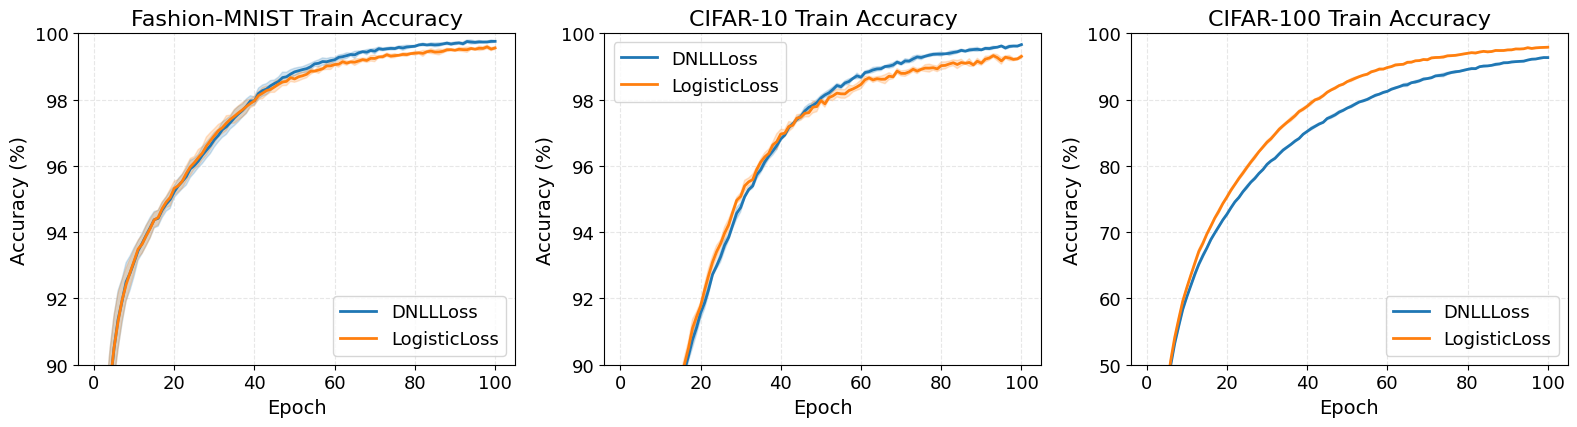

In [5]:
fig, axes = plt.subplots(1, len(results_by_dataset), figsize=(16, 4.5), sharey=False)

for ax, (dataset_name, results) in zip(axes, results_by_dataset.items()):
    losses = results['losses']
    for loss_name, loss_runs in losses.items():
        plot_metric(ax, loss_runs, 'train_acc', loss_name, colors[loss_name])
    ax.set_title(f'{dataset_name} Train Accuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(train_ylims[dataset_name])
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig('lda_train_accuracy.png', dpi=600)


/tmp/ipykernel_111461/796903651.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([dnll_final, log_final], labels=['DNLLLoss', 'LogisticLoss'])
/tmp/ipykernel_111461/796903651.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([dnll_final, log_final], labels=['DNLLLoss', 'LogisticLoss'])
/tmp/ipykernel_111461/796903651.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([dnll_final, log_final], labels=['DNLLLoss', 'LogisticLoss'])


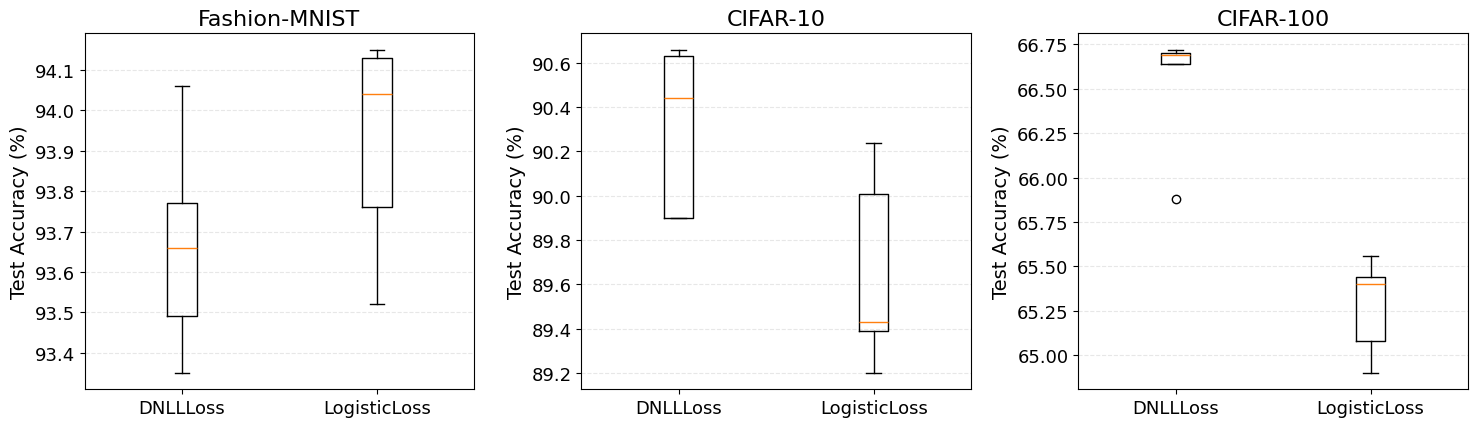

In [6]:
def final_accuracy(loss_runs, key):
    values = stack_metric(loss_runs, key)
    scale = 100 if key.endswith('acc') else 1
    return values[:, -1] * scale

fig, axes = plt.subplots(1, len(results_by_dataset), figsize=(15, 4.5), sharey=False)

for ax, (dataset_name, results) in zip(axes, results_by_dataset.items()):
    losses = results['losses']
    dnll_final = final_accuracy(losses['DNLLLoss'], 'test_acc')
    log_final = final_accuracy(losses['LogisticLoss'], 'test_acc')
    ax.boxplot([dnll_final, log_final], labels=['DNLLLoss', 'LogisticLoss'])
    ax.set_title(dataset_name)
    ax.set_ylabel('Test Accuracy (%)')
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('lda_final_acc.png', dpi=600)


In [7]:
def final_accuracy_summary(loss_runs, key='test_acc'):
    values = final_accuracy(loss_runs, key)
    return values.mean(), values.std()

loss_names = ['DNLLLoss', 'LogisticLoss']
dataset_names = list(results_by_dataset.keys())
rows = []
for loss_name in loss_names:
    row = [loss_name]
    for dataset_name in dataset_names:
        mean, std = final_accuracy_summary(results_by_dataset[dataset_name]['losses'][loss_name])
        row.append(f'{mean:.2f} $\\pm$ {std:.2f}')
    rows.append(row)

latex_lines = [
    r'\begin{table}[ht]',
    r'\centering',
    r'\begin{tabular}{l' + 'c' * len(dataset_names) + '}',
    r'\hline',
    'Loss & ' + ' & '.join(dataset_names) + r' \\',
    r'\hline',
]
latex_lines.extend(row[0] + ' & ' + ' & '.join(row[1:]) + r' \\' for row in rows)
latex_lines.extend([
    r'\hline',
    r'\end{tabular}',
    r'\caption{Final test accuracy, mean $\pm$ standard deviation over runs (\%).}',
    r'\label{tab:lda-final-test-accuracy}',
    r'\end{table}',
])
print('\n'.join(latex_lines))


\begin{table}[ht]
\centering
\begin{tabular}{lccc}
\hline
Loss & Fashion-MNIST & CIFAR-10 & CIFAR-100 \\
\hline
DNLLLoss & 93.67 $\pm$ 0.24 & 90.31 $\pm$ 0.34 & 66.53 $\pm$ 0.32 \\
LogisticLoss & 93.92 $\pm$ 0.24 & 89.65 $\pm$ 0.40 & 65.28 $\pm$ 0.25 \\
\hline
\end{tabular}
\caption{Final test accuracy, mean $\pm$ standard deviation over runs (\%).}
\label{tab:lda-final-test-accuracy}
\end{table}


## ResNet50 Deep LDA Results

Report results from `resnet50_lda_runs.json`.


In [8]:
from statistics import mean, pstdev

resnet50_results_path = Path('resnet50_lda_runs.json')
with resnet50_results_path.open() as f:
    resnet50_results = json.load(f)

resnet50_display_names = {
    'FashionMNIST': 'Fashion-MNIST',
    'CIFAR10': 'CIFAR-10',
    'CIFAR100': 'CIFAR-100',
}


def resnet50_final_accuracy_summary(loss_runs, key='test_acc'):
    values = [run[key][-1] * 100 for run in loss_runs]
    return mean(values), pstdev(values)


print('ResNet50 run metadata')
for key, value in resnet50_results['meta'].items():
    print(f'{key}: {value}')

loss_names = ['DNLLLoss', 'LogisticLoss']
resnet50_dataset_keys = list(resnet50_results['results'].keys())
resnet50_dataset_names = [resnet50_display_names.get(key, key) for key in resnet50_dataset_keys]
rows = []
for loss_name in loss_names:
    row = [loss_name]
    for dataset_key in resnet50_dataset_keys:
        mean_acc, std_acc = resnet50_final_accuracy_summary(
            resnet50_results['results'][dataset_key][loss_name]
        )
        row.append(f'{mean_acc:.2f} $\\pm$ {std_acc:.2f}')
    rows.append(row)

latex_lines = [
    r'\begin{table}[ht]',
    r'\centering',
    r'\begin{tabular}{l' + 'c' * len(resnet50_dataset_names) + '}',
    r'\hline',
    'Loss & ' + ' & '.join(resnet50_dataset_names) + r' \\',
    r'\hline',
]
latex_lines.extend(row[0] + ' & ' + ' & '.join(row[1:]) + r' \\' for row in rows)
latex_lines.extend([
    r'\hline',
    r'\end{tabular}',
    r'\caption{ResNet50 final test accuracy, mean $\pm$ standard deviation over runs (\%).}',
    r'\label{tab:resnet50-lda-final-test-accuracy}',
    r'\end{table}',
])
print('\n'.join(latex_lines))


ResNet50 run metadata
datasets: ['Fashion-MNIST', 'CIFAR-10', 'CIFAR-100']
epochs: 100
runs: 5
batch_size: 128
test_batch_size: 512
covariance_type: spherical
encoder: ResNet50
pretrained: True
optimizer: Adam
lr: 0.0001
lambda_reg: 1.0
seed_base: 1234
deterministic: False
device: cuda
timestamp: 2026-05-05T21:44:53
\begin{table}[ht]
\centering
\begin{tabular}{lccc}
\hline
Loss & Fashion-MNIST & CIFAR-10 & CIFAR-100 \\
\hline
DNLLLoss & 94.25 $\pm$ 0.19 & 96.34 $\pm$ 0.17 & 81.15 $\pm$ 0.14 \\
LogisticLoss & 93.95 $\pm$ 0.32 & 96.36 $\pm$ 0.17 & 81.11 $\pm$ 0.28 \\
\hline
\end{tabular}
\caption{ResNet50 final test accuracy, mean $\pm$ standard deviation over runs (\%).}
\label{tab:resnet50-lda-final-test-accuracy}
\end{table}


In [9]:
resnet50_ylims = {
    'Fashion-MNIST': (92, 98),
    'CIFAR-10': (92, 98),
    'CIFAR-100': (75, 85),
}

resnet50_train_ylims = {
    'Fashion-MNIST': (90, 98),
    'CIFAR-10': (90, 98),
    'CIFAR-100': (85, 95),
}

resnet50_results_by_dataset = {
    resnet50_display_names.get(dataset_key, dataset_key): losses
    for dataset_key, losses in resnet50_results['results'].items()
}


def stack_resnet50_metric(loss_runs, key):
    return np.array([run[key] for run in loss_runs], dtype=np.float32)


def summarize_resnet50_metric(loss_runs, key):
    values = stack_resnet50_metric(loss_runs, key)
    mean_values = values.mean(axis=0)
    std_values = values.std(axis=0)
    return mean_values, std_values


def plot_resnet50_metric(ax, loss_runs, key, label, color):
    mean_values, std_values = summarize_resnet50_metric(loss_runs, key)
    epochs = np.arange(1, len(mean_values) + 1)
    scale = 100 if key.endswith('acc') else 1
    ax.plot(epochs, mean_values * scale, label=label, color=color, linewidth=2)
    ax.fill_between(
        epochs,
        (mean_values - std_values) * scale,
        (mean_values + std_values) * scale,
        color=color,
        alpha=0.2,
    )
    return mean_values, std_values


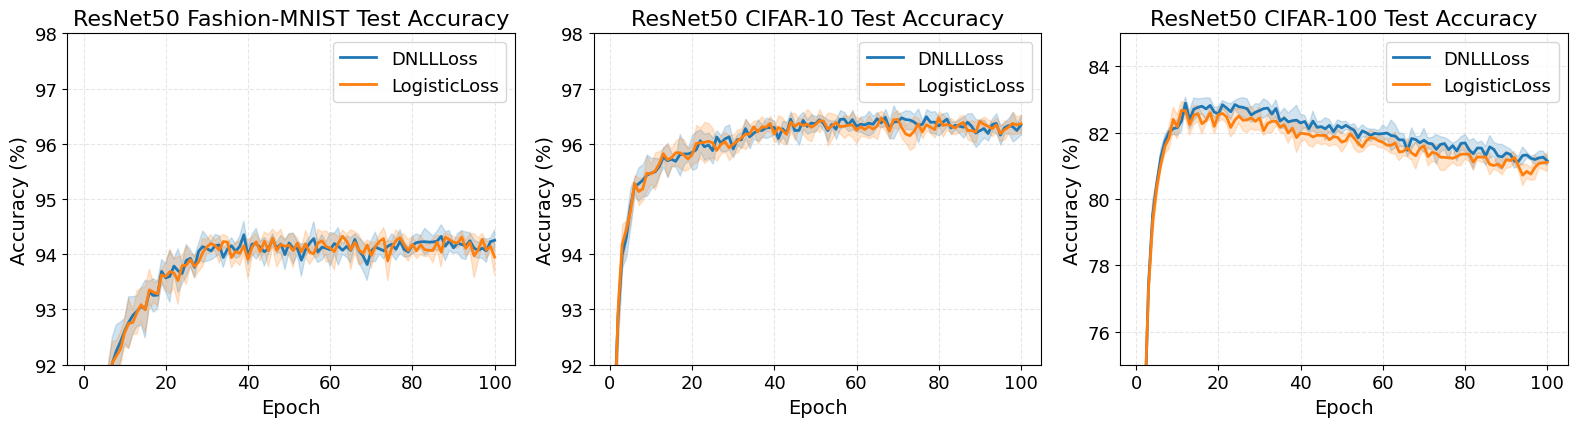

In [10]:
fig, axes = plt.subplots(1, len(resnet50_results_by_dataset), figsize=(16, 4.5), sharey=False)

for ax, (dataset_name, losses) in zip(axes, resnet50_results_by_dataset.items()):
    for loss_name, loss_runs in losses.items():
        plot_resnet50_metric(ax, loss_runs, 'test_acc', loss_name, colors[loss_name])
    ax.set_title(f'ResNet50 {dataset_name} Test Accuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(resnet50_ylims[dataset_name])
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig('resnet50_lda_runs_comparison.png', dpi=600)


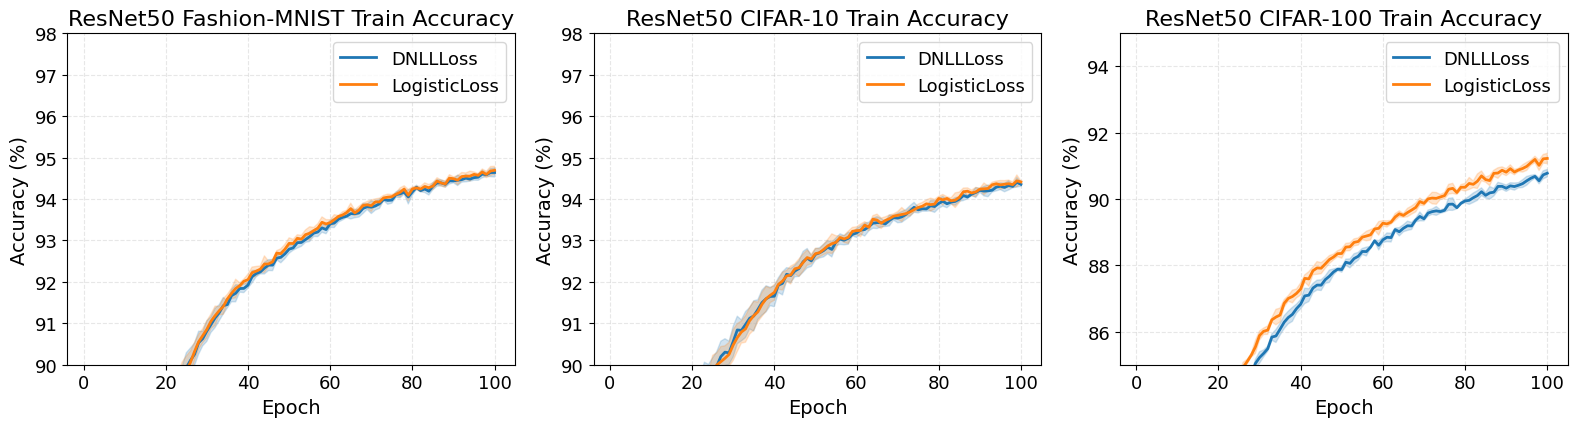

In [11]:
fig, axes = plt.subplots(1, len(resnet50_results_by_dataset), figsize=(16, 4.5), sharey=False)

for ax, (dataset_name, losses) in zip(axes, resnet50_results_by_dataset.items()):
    for loss_name, loss_runs in losses.items():
        plot_resnet50_metric(ax, loss_runs, 'train_acc', loss_name, colors[loss_name])
    ax.set_title(f'ResNet50 {dataset_name} Train Accuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(resnet50_train_ylims[dataset_name])
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig('resnet50_lda_train_accuracy.png', dpi=600)


/tmp/ipykernel_111461/741291790.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([dnll_final, log_final], labels=['DNLLLoss', 'LogisticLoss'])
/tmp/ipykernel_111461/741291790.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([dnll_final, log_final], labels=['DNLLLoss', 'LogisticLoss'])
/tmp/ipykernel_111461/741291790.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([dnll_final, log_final], labels=['DNLLLoss', 'LogisticLoss'])


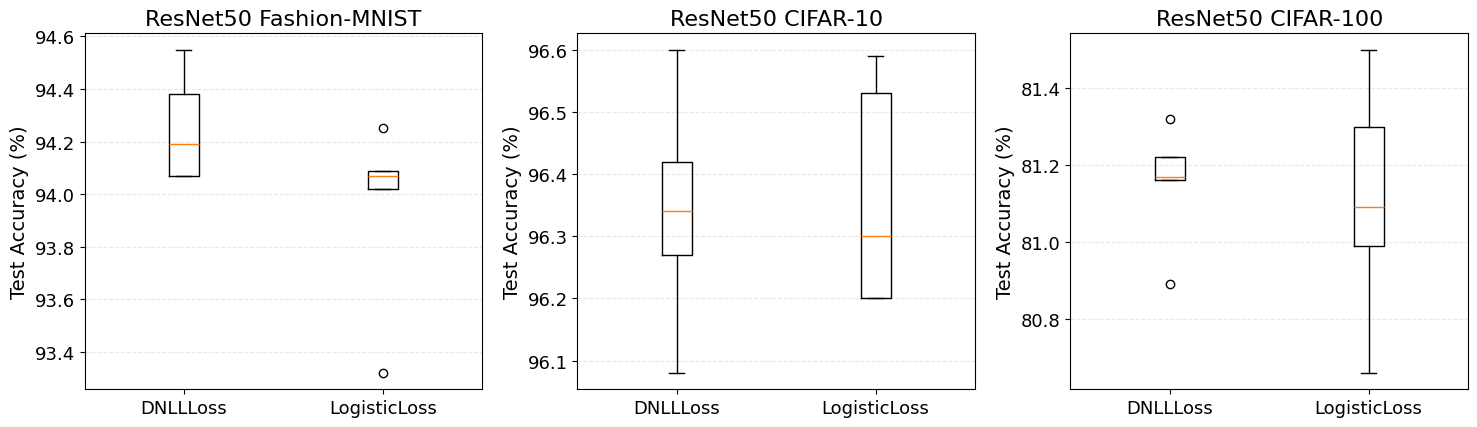

In [12]:
def resnet50_final_accuracy(loss_runs, key):
    values = stack_resnet50_metric(loss_runs, key)
    scale = 100 if key.endswith('acc') else 1
    return values[:, -1] * scale

fig, axes = plt.subplots(1, len(resnet50_results_by_dataset), figsize=(15, 4.5), sharey=False)

for ax, (dataset_name, losses) in zip(axes, resnet50_results_by_dataset.items()):
    dnll_final = resnet50_final_accuracy(losses['DNLLLoss'], 'test_acc')
    log_final = resnet50_final_accuracy(losses['LogisticLoss'], 'test_acc')
    ax.boxplot([dnll_final, log_final], labels=['DNLLLoss', 'LogisticLoss'])
    ax.set_title(f'ResNet50 {dataset_name}')
    ax.set_ylabel('Test Accuracy (%)')
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('resnet50_lda_final_acc.png', dpi=600)
